In [1]:
!pip install scikit-learn

In [2]:
!pip install tensorflow opencv-python

In [61]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import pandas as pd
import cv2
from sklearn.utils import shuffle
import re
import tensorflow as tf
from tensorflow.keras.regularizers import l2


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [6]:
videos = []
classes = []

path ="/content/drive/My Drive/VideosProyecto"
normal= os.path.join(path, "normal")
suspicious = os.path.join(path, "abnormal")

videos = []
labelsDict = {0: "Normal", 1: "Abnormal"}
labels = []

for video in os.listdir(normal):
    videos.append(os.path.join(normal, video))
    labels.append(0)

for video in os.listdir(suspicious):
    videos.append(os.path.join(suspicious, video))
    labels.append(1)

df = pd.DataFrame({"videos": videos, "classes": labels})
df['videos'] = videos
df['classes'] = labels

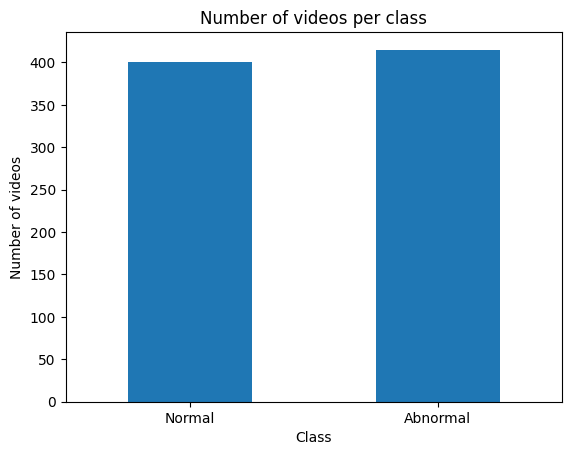

In [7]:
counts = df["classes"].value_counts().sort_index()

counts.plot(kind="bar")
plt.xticks(ticks=[0, 1], labels=["Normal", "Abnormal"], rotation=0)
plt.title("Number of videos per class")
plt.xlabel("Class")
plt.ylabel("Number of videos")
plt.show()

In [8]:
IMG_SIZE = 112
SEQUENCE_LENGTH = 25


def load_video(video_path, max_frames=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)
    cap.release()

    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.array(frames, dtype=np.float32) / 255.0

In [9]:
df["videos"] = df["videos"].apply(load_video)

X_train, X_test, y_train, y_test = train_test_split(
    df["videos"], df["classes"], test_size=0.2, random_state=42, stratify=df["classes"]
)

In [10]:
unique, counts = np.unique(y_train, return_counts=True)
print(f"Videos de entrenamiento por clase: {dict(zip(unique, counts))}")

unique, counts = np.unique(y_test, return_counts=True)
print(f"Videos de validación por clase: {dict(zip(unique, counts))}")

Videos de entrenamiento por clase: {np.int64(0): np.int64(320), np.int64(1): np.int64(332)}
Videos de validación por clase: {np.int64(0): np.int64(80), np.int64(1): np.int64(83)}


In [11]:
X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())

In [66]:
def create_3d_cnn(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv3D(32, kernel_size=(1,3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Conv3D(64, kernel_size=(3, 1, 1), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Conv3D(128, kernel_size=(1, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),


        tf.keras.layers.Conv3D(256, kernel_size=(1, 3, 3), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

input_shape = (SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=6, verbose=0, restore_best_weights=True)

with tf.device('/device:GPU:0'):
  model = create_3d_cnn(input_shape)
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_60 (Conv3D)              │ (None, 25, 110, 110,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_59 (MaxPooling3D) │ (None, 12, 55, 55, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 12, 55, 55, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_61 (Conv3D)              │ (None, 10, 55, 55, 64) │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_60 (MaxPooling3D) │ (None, 5, 27, 27, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 5, 27, 27, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_62 (Conv3D)              │ (None, 5, 25, 25, 128) │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_61 (MaxPooling3D) │ (None, 2, 12, 12, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 2, 12, 12, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_63 (Conv3D)              │ (None, 2, 10, 10, 256) │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_62 (MaxPooling3D) │ (None, 1, 5, 5, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 1, 5, 5, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,197,634 (4.57 MB)

 Trainable params: 1,196,674 (4.56 MB)

 Non-trainable params: 960 (3.75 KB)

In [67]:
with tf.device('/device:GPU:0'):
  history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), callbacks=[earlyStopping])

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.6317 - loss: 2.3011 - val_accuracy: 0.6258 - val_loss: 0.6648
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6929 - loss: 1.3748 - val_accuracy: 0.4908 - val_loss: 2.7677
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7686 - loss: 0.8567 - val_accuracy: 0.4908 - val_loss: 2.1113
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8638 - loss: 0.5370 - val_accuracy: 0.6687 - val_loss: 0.8017
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8431 - loss: 0.5491 - val_accuracy: 0.8712 - val_loss: 0.4228
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8903 - loss: 0.2975 - val_accuracy: 0.9080 - val_loss: 0.3774
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8994 - loss: 0.2524 - val_accuracy: 0.8466 - val_loss: 0.4448
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9159 - loss: 0.2293 - val_accuracy: 0.9080 -

In [68]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9071 - loss: 0.3797
Loss: 0.3774406909942627, Accuracy: 0.907975435256958


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        80
           1       0.87      0.96      0.91        83

    accuracy                           0.91       163
   macro avg       0.91      0.91      0.91       163
weighted avg       0.91      0.91      0.91       163



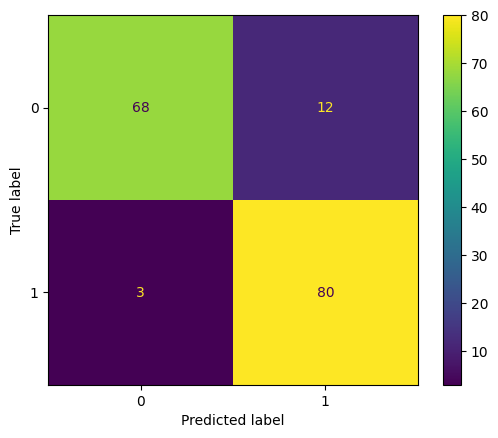

In [69]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot()

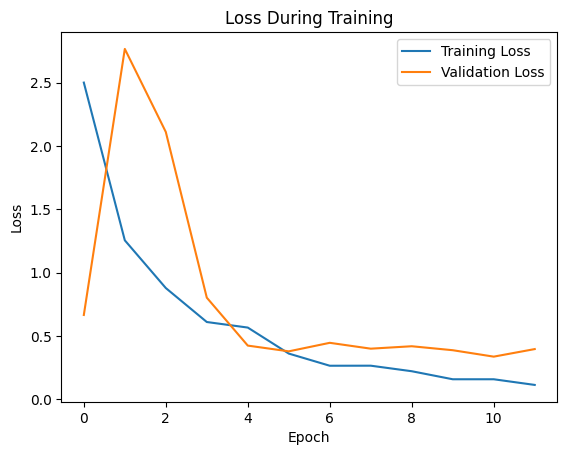

In [70]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss During Training')
plt.show()

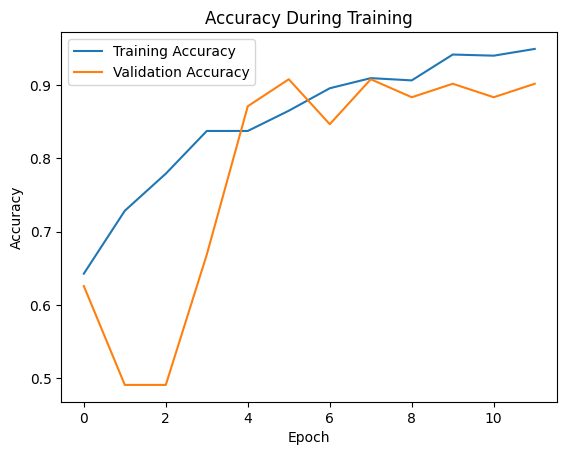

In [71]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy During Training')
plt.show()

In [72]:
model.save('modelSuspicious.h5')
model.save('modelo.keras')